# Direct Collocation for a Pendulum Swing-Up

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pierrelux/rlbook/blob/main/lab/notebooks/08_collocation_from_nodes.ipynb)

This demo applies the direct-collocation recipe of the chapter
[Continuous-Time Transcription and Collocation](https://pierrelux.github.io/rlbook/continuous-time-collocation) to a small nonlinear
control problem. The chapter develops the recipe for general dynamics and
general choices of nodes. Here every step is carried out once with concrete
numbers and then written as a few lines of Python, so that each symbol of the
recipe can be matched with a quantity in the code. The text explains why each
step is needed as well as what it computes.

The demo runs in a few seconds with NumPy, SciPy, and Matplotlib and needs no
other files. Run the cells in order.

## The Problem

A pendulum hangs at rest below its pivot, where a motor applies a torque
$u(t)$. At time $T=4$ the pendulum must stand upright and at rest, and the
motor should use as little torque as possible. Let $\theta$ be the angle
measured from the hanging position and $\omega$ the angular velocity. Time is
measured in units of $\sqrt{\ell/g}$ and torque in units of $mg\ell$, where
$m$ is the mass, $\ell$ the length, and $g$ the gravitational acceleration.
In these units the state $\mathbf x=(\theta,\omega)$ evolves according to

$$
\dot\theta=\omega,\qquad \dot\omega=-\sin\theta+u.
$$

The term $-\sin\theta$ is gravity, which pulls the pendulum back toward the
hanging position. Writing the dynamics as $\dot{\mathbf x}=\mathbf f(\mathbf x,u)$,
the optimal control problem is

$$
\min_{\mathbf x(\cdot),u(\cdot)} \int_0^T u(t)^2 dt
\quad\text{subject to}\quad
\dot{\mathbf x}=\mathbf f(\mathbf x,u),\quad
\mathbf x(0)=(0,0),\quad
\mathbf x(T)=(\pi,0).
$$

Because of $\sin\theta$, the dynamics are nonlinear, and neither the optimal
torque nor the resulting motion has a closed-form expression.

## From Functions to Numbers

SciPy's `minimize`, like every nonlinear programming solver, works with a
finite vector $\mathbf z$ of unknowns. It needs a function $F(\mathbf z)$ that
returns the objective and a function $H(\mathbf z)$ that returns constraint
residuals, which must be zero at a solution. The problem above provides
neither. Its unknowns are the functions $\theta(t)$, $\omega(t)$, and $u(t)$,
its constraint is a condition on a derivative at every instant, and its
objective is an integral. Transcription replaces these objects by finitely
many numbers and algebraic equations.

Direct collocation makes three replacements. First, the horizon is divided
into $N$ intervals, and on each interval the state is described by a
polynomial. A polynomial of low degree is determined by a few numbers, and
its derivative and integral can be computed exactly from those numbers.
Second, the differential equation is required only at a few chosen times per
interval, the **collocation nodes**, where the slope of the polynomial must
equal the slope given by $\mathbf f$. Third, the cost integral is replaced by
a weighted sum of cost rates at the same nodes. After these replacements,
every condition is an equation between numbers, which the optimizer can
evaluate for any candidate $\mathbf z$.

Many short intervals are used instead of one polynomial over $[0,T]$. This
keeps the degree of each polynomial low, lets the accuracy improve by adding
intervals, and makes each equation involve only the numbers of one interval.

The sections below follow the steps of the chapter's
[integration-form algorithm](https://pierrelux.github.io/rlbook/continuous-time-collocation#alg-collocation-from-nodes). Step 1
computes fixed numbers that describe the polynomials. Steps 2 to 4 define
$\mathbf z$, $F$, and $H$. Step 5 solves the problem and checks the answer
against an accurate simulation. A final section builds the same problem from
derivatives instead of integrals.

The first cell defines the model. The rest of the demo uses the dynamics only
through calls `f(x, u)` and the cost only through calls `c(x, u)`, so another
model would change only this cell.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
from numpy.polynomial import Polynomial
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})


def f(x, u):
    # Pendulum dynamics: x = (angle, angular velocity), u = torque.
    theta, omega = x
    return np.array([omega, -np.sin(theta) + u])


def c(x, u):
    # Running cost rate.
    return u**2


T = 4.0
x_start = np.array([0.0, 0.0])     # hanging, at rest
x_goal = np.array([np.pi, 0.0])    # upright, at rest

## Step 1: Compute the Rule Once

Divide $[0,T]$ into $N$ intervals of width $h=T/N$, with interval $k$ starting
at $t_k=kh$. Inside interval $k$, measure time by the **local time**
$\tau=(t-t_k)/h$, which runs from $0$ at the left end to $1$ at the right end.
Every interval then looks the same in local time, so the numbers computed in
this step on $[0,1]$ serve every interval.

Suppose for a moment that the slopes of the state at two collocation nodes
$\tau_1$ and $\tau_2$ of interval $k$ were known, and call them
$\mathbf f_{k,1}$ and $\mathbf f_{k,2}$. The simplest function of $\tau$ that
takes these two values at the two nodes is the line

$$
\mathbf f_{k,1}\ell_1(\tau)+\mathbf f_{k,2}\ell_2(\tau),
$$

where the **Lagrange basis function** $\ell_j$ equals one at $\tau_j$ and zero
at the other node. Integrating this interpolated slope, starting from the
state $\mathbf x_k$ at the left end, gives the state inside the interval:

$$
\mathbf x(t_k+h\tau)\approx\mathbf x_k
+h\sum_{j=1}^{2}\mathbf f_{k,j}\int_0^{\tau}\ell_j(\sigma)d\sigma .
$$

The factor $h$ converts time units. The slopes are rates per unit of physical
time, and a stretch $d\sigma$ of local time lasts $h d\sigma$ units of
physical time.

The slopes $\mathbf f_{k,j}$ are numbers that multiply fixed functions, so the
only integrals ever needed are integrals of $\ell_1$ and $\ell_2$, and those
depend on the nodes alone. Evaluating them at the nodes and at the right end
gives the **rule** of the method:

$$
A_{ij}=\int_0^{\tau_i}\ell_j(\tau)d\tau,
\qquad
b_j=\int_0^1\ell_j(\tau)d\tau.
$$

The entry $A_{ij}$ is the share of slope $j$ in the state change from the left
end to node $i$, per unit of interval width. The weight $b_j$ is the share of
slope $j$ in the change over the whole interval.

This demo uses the nodes $\tau_1=\tfrac{1}{3}$ and $\tau_2=1$, called the
two-stage Radau nodes. Their basis functions are

$$
\ell_1(\tau)=\frac{\tau-1}{\tfrac{1}{3}-1}=\frac{3}{2}(1-\tau),
\qquad
\ell_2(\tau)=\frac{\tau-\tfrac{1}{3}}{1-\tfrac{1}{3}}=\frac{1}{2}(3\tau-1).
$$

The antiderivatives that vanish at $0$ are
$L_1(\tau)=\tfrac{3}{2}\tau-\tfrac{3}{4}\tau^2$ and
$L_2(\tau)=\tfrac{3}{4}\tau^2-\tfrac{1}{2}\tau$, so every entry of the rule is
one evaluation:

$$
A=\begin{bmatrix}
L_1(\tfrac{1}{3})&L_2(\tfrac{1}{3})\cr
L_1(1)&L_2(1)
\end{bmatrix}
=\begin{bmatrix}
\tfrac{5}{12}&-\tfrac{1}{12}\cr
\tfrac{3}{4}&\tfrac{1}{4}
\end{bmatrix},
\qquad
b=\begin{bmatrix}L_1(1)\cr L_2(1)\end{bmatrix}
=\begin{bmatrix}\tfrac{3}{4}\cr \tfrac{1}{4}\end{bmatrix}.
$$

The code performs the same three operations for any distinct nodes: it
multiplies the linear factors of each $\ell_j$, integrates, and evaluates.

In [2]:
tau = np.array([1/3, 1.0])         # collocation nodes


def lagrange_basis(nodes):
    # ell_j(tau) = product over m != j of (tau - tau_m) / (tau_j - tau_m).
    # Polynomial([-tau_m, 1.0]) is the factor tau - tau_m.
    basis = []
    for j, tau_j in enumerate(nodes):
        ell = Polynomial([1.0])
        for m, tau_m in enumerate(nodes):
            if m != j:
                ell = ell * Polynomial([-tau_m, 1.0]) / (tau_j - tau_m)
        basis.append(ell)
    return basis


# A[i, j] is the integral of ell_j from 0 to tau_i, and b[j] its integral from 0 to 1.
L = [ell.integ() for ell in lagrange_basis(tau)]     # antiderivatives with L_j(0) = 0
A = np.array([[L_j(tau_i) for L_j in L] for tau_i in tau])
b = np.array([L_j(1.0) for L_j in L])


def frac(value):
    # Round a number to a nearby fraction, to compare with the hand calculation.
    return str(Fraction(value).limit_denominator(1000))


def show(name, array):
    print(name, "=", str(np.vectorize(frac)(array).tolist()).replace("'", ""))


show("A", A)
show("b", b)
show("row sums of A", A.sum(axis=1))
show("sum of b", b.sum())

A = [[5/12, -1/12], [3/4, 1/4]]
b = [3/4, 1/4]
row sums of A = [1/3, 1]
sum of b = 1


In `lagrange_basis`, the polynomial `Polynomial([-tau_m, 1.0])` is
$\tau-\tau_m$, which vanishes at node $m$. Dividing by $\tau_j-\tau_m$ makes
the product equal one at $\tau_j$. The method `.integ()` returns the
antiderivative whose value at $0$ is zero, so `L_j(tau_i)` is the integral
from $0$ to $\tau_i$. These are exact operations on polynomial coefficients,
and no numerical integration is involved. The printed arrays agree with the
hand calculation.

The row sums of $A$ equal the nodes, and the weights $b$ sum to one. Both
facts follow from the meaning of the rule. If every slope equals the same
value $\mathbf f$, the state changes by $h\tau_i\mathbf f$ between the left
end and node $i$, and by $h\mathbf f$ over the whole interval. A rule that
failed this check would not reproduce motion at constant velocity.

The figure below draws each basis function and shows the entries of the rule
as signed areas under it.

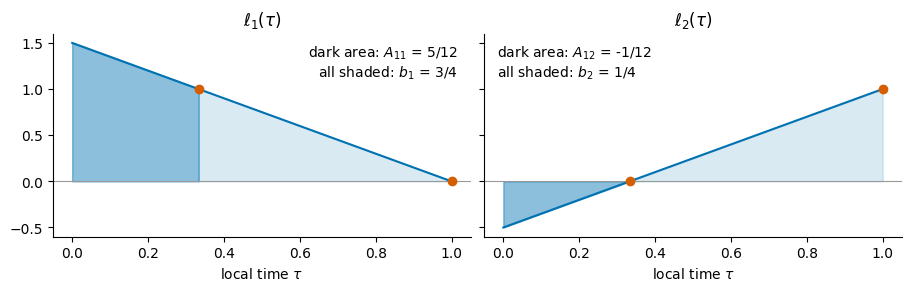

In [3]:
# @title Plot each basis function and the areas that form A and b
fig, axes = plt.subplots(1, len(tau), figsize=(4.5 * len(tau), 2.8), squeeze=False,
                         sharey=True, constrained_layout=True)
grid = np.linspace(0, 1, 200)
for j, (ax, ell) in enumerate(zip(axes[0], lagrange_basis(tau))):
    to_node, to_end = np.linspace(0, tau[0], 50), np.linspace(tau[0], 1, 100)
    ax.axhline(0, color="0.6", linewidth=0.8)
    ax.fill_between(to_node, ell(to_node), color="#0072B2", alpha=0.45)
    ax.fill_between(to_end, ell(to_end), color="#0072B2", alpha=0.15)
    ax.plot(grid, ell(grid), color="#0072B2")
    ax.plot(tau, ell(tau), "o", color="#D55E00")
    ax.set(xlabel=r"local time $\tau$", title=rf"$\ell_{{{j + 1}}}(\tau)$")
    label = (rf"dark area: $A_{{1{j + 1}}}$ = {frac(A[0, j])}" "\n"
             rf"all shaded: $b_{{{j + 1}}}$ = {frac(b[j])}")
    left = ell(0) < ell(1)          # write the label on the side where the curve is low
    ax.text(0.03 if left else 0.97, 0.95, label, transform=ax.transAxes,
            ha="left" if left else "right", va="top")
plt.show()

The orange dots mark the nodes, where each basis function equals one or zero.
The entry $A_{12}=-\tfrac{1}{12}$ is negative because $\ell_2$ is negative
between $0$ and $\tfrac{1}{3}$, and a negative weight is not an error. The
interpolated slope is a line through $\mathbf f_{k,1}$ at $\tau=\tfrac{1}{3}$
and $\mathbf f_{k,2}$ at $\tau=1$. Increasing $\mathbf f_{k,2}$ while
$\mathbf f_{k,1}$ stays fixed tilts this line upward to the right of
$\tau=\tfrac{1}{3}$ and downward to its left, so the state gains less before
the first node.

Any distinct nodes produce a valid rule, but the choice affects accuracy. The
Radau nodes make the weights $b$ integrate every polynomial of degree up to
two exactly. For example,
$\tfrac{3}{4}(\tfrac{1}{3})^2+\tfrac{1}{4}(1)^2=\tfrac{1}{3}$, which equals
$\int_0^1\tau^2d\tau$. Two nodes at the ends of the interval, which give the
trapezoidal rule, integrate only polynomials of degree up to one exactly. The
experiments at the end compare several node choices on the pendulum.

The arrays $A$ and $b$ are computed once, before any optimization, and stay
fixed while the optimizer searches.

## Step 2: Allocate the Variables

The rule needs the slopes at the nodes,
$\mathbf f_{k,j}=\mathbf f(\mathbf x_{k,j},u_k)$, and those depend on the
states at the nodes, which are unknown before the problem is solved. Direct
collocation does not compute these states by simulation. It makes them
unknowns of the optimization and adds equations, in Step 3, that make them
consistent. On interval $k$ the unknowns are:

```
local time        0            1/3                          1
                  |-------------|---------------------------|
mesh states   x_mesh[k]                                x_mesh[k+1]
stage states              x_stage[k, 0]               x_stage[k, 1]
torque            <----------------- u[k] ------------------>
```

The **mesh state** $\mathbf x_k$ is the state at the left end $t_k$. The
preceding interval ends at the same time and uses the same variable, and this
sharing keeps the trajectory continuous. The **stage states**
$\mathbf x_{k,1}$ and $\mathbf x_{k,2}$ are the states at the two nodes. The
torque $u_k$ is held constant over the interval, which is the simplest
control representation. In the chapter's notation, the control matrix $B$ is
then a column of ones. A linear or quadratic torque would add numbers per
interval without changing the construction of the state.

All states and torques are unknowns at the same time, and no simulation runs
inside the optimizer. This is why direct collocation is called a simultaneous
method. In single shooting, by contrast, the optimizer chooses only the
torques, and a time integrator computes the states.

Python counts from zero, so the stage state $\mathbf x_{k,j}$ is stored in
`x_stage[k, j-1]`. The solver needs all unknowns in one flat vector
$\mathbf z$, and the function `unpack` cuts that vector into the three arrays.

In [4]:
N = 20                              # intervals
h = T / N                           # interval width
s = len(tau)                        # stages per interval
n = len(x_start)                    # state dimension
n_z = (N + 1) * n + N * s * n + N   # number of unknowns


def unpack(z):
    x_mesh = z[:(N + 1) * n].reshape(N + 1, n)      # x_mesh[k] is the mesh state x_k
    x_stage = z[(N + 1) * n:-N].reshape(N, s, n)    # x_stage[k, j] is a stage state
    u = z[-N:]                                      # u[k] is the torque on interval k
    return x_mesh, x_stage, u


print("number of unknowns:", n_z)

number of unknowns: 142


The count consists of $21\times2$ mesh-state entries, $20\times2\times2$
stage-state entries, and $20$ torques.

## Step 3: Assemble Each Interval

The slopes $\mathbf f_{k,j}=\mathbf f(\mathbf x_{k,j},u_k)$ are now computed
from the unknowns, so they change whenever the optimizer changes
$\mathbf z$. The rule $A$, $b$ does not change. Evaluating the integrated
slope polynomial of Step 1 at each node and at the right end gives the
chapter's **stage equations** and **endpoint equation**:

$$
\mathbf x_{k,i}=\mathbf x_k+h\sum_{j=1}^{s}A_{ij}\mathbf f_{k,j},
\qquad
\mathbf x_{k+1}=\mathbf x_k+h\sum_{j=1}^{s}b_j\mathbf f_{k,j}.
$$

The stage equation for node $i$ requires the stored stage state
$\mathbf x_{k,i}$ to lie on the polynomial built from the slopes. It is needed
because the slopes were evaluated at the stored stage states. If those states
could differ from the polynomial's values, the slopes would describe some other
trajectory. When the stage equation holds, the polynomial has the value
$\mathbf x_{k,i}$ at node $i$, and its slope there is $\mathbf f_{k,i}$ by
construction of the interpolant. The polynomial therefore satisfies the
differential equation at node $i$, which is what the word collocation refers
to.

The endpoint equation requires the next mesh state to equal the value of the
polynomial at the right end of the interval. The difference between its two
sides is called the **defect**. Because $\mathbf x_{k+1}$ is also the starting
state of interval $k+1$, a zero defect joins consecutive pieces into one
continuous trajectory.

With the numbers from Step 1, the three equations read

$$
\begin{aligned}
\mathbf x_{k,1}&=\mathbf x_k
+h\left(\tfrac{5}{12}\mathbf f_{k,1}-\tfrac{1}{12}\mathbf f_{k,2}\right),\cr
\mathbf x_{k,2}&=\mathbf x_k
+h\left(\tfrac{3}{4}\mathbf f_{k,1}+\tfrac{1}{4}\mathbf f_{k,2}\right),\cr
\mathbf x_{k+1}&=\mathbf x_k
+h\left(\tfrac{3}{4}\mathbf f_{k,1}+\tfrac{1}{4}\mathbf f_{k,2}\right).
\end{aligned}
$$

The first two use the rows of $A$ and the third uses $b$. Because $\tau_2=1$,
the last two have the same right side, so they imply
$\mathbf x_{k,2}=\mathbf x_{k+1}$. The code keeps both variables and both
equations anyway, so that it stays valid for nodes that do not include the
right end.

The objective is built the same way. The cost accumulated since time $0$
behaves like an extra state whose slope is the cost rate $c(\mathbf x,u)$, so
the same weights $b$ integrate it. Interval $k$ adds
$h(\tfrac{3}{4}c_{k,1}+\tfrac{1}{4}c_{k,2})$ to the objective, where
$c_{k,j}=c(\mathbf x_{k,j},u_k)$. Here $c=u_k^2$ is constant on the interval
and the weights sum to one, so this sum equals $hu_k^2$, the exact integral of
the squared torque over the interval. The boundary conditions
$\mathbf x_0=(0,0)$ and $\mathbf x_N=(\pi,0)$ complete the finite problem.

In [5]:
def objective(z):                                                       # F(z)
    x_mesh, x_stage, u = unpack(z)
    return sum(h * b[j] * c(x_stage[k, j], u[k]) for k in range(N) for j in range(s))


def equalities(z):                                                      # H(z) = 0
    x_mesh, x_stage, u = unpack(z)
    residuals = [x_mesh[0] - x_start, x_mesh[N] - x_goal]               # boundary conditions
    for k in range(N):
        slopes = np.array([f(x_stage[k, j], u[k]) for j in range(s)])   # f at every stage
        residuals.append(x_stage[k] - x_mesh[k] - h * A @ slopes)       # stage equations
        residuals.append(x_mesh[k + 1] - x_mesh[k] - h * b @ slopes)    # endpoint equation
    return np.concatenate([r.ravel() for r in residuals])


print("number of equations:", equalities(np.zeros(n_z)).size)

number of equations: 124


In `equalities`, the array `slopes` has one row per stage and one column per
state component. The product `A @ slopes` computes all the sums
$\sum_jA_{ij}\mathbf f_{k,j}$ at once, one row per node $i$, and `b @ slopes`
computes the endpoint sum. Each residual is written as left side minus right
side, so a solution makes it zero. The last line flattens the residuals into
the single vector $H(\mathbf z)$ that the solver expects.

The count of equations explains what the optimizer is free to choose. The 120
stage and endpoint equations match the 120 states other than $\mathbf x_0$,
so for given torques they determine the whole trajectory, as a simulation
would. The four boundary equations fix $\mathbf x_0$ and impose two terminal
conditions, which leave $20-2=18$ degrees of freedom in the torques. Among the
torque sequences that bring the pendulum to the goal, the objective selects
the one with the least effort.

The table collects the correspondence between the chapter's symbols and the
code.

| Chapter | Code | Meaning |
|:--|:--|:--|
| $\tau_j$ | `tau[j-1]` | collocation node $j$, in local time |
| $\ell_j$, $L_j$ | `lagrange_basis(tau)[j-1]`, `L[j-1]` | basis function and its antiderivative |
| $A_{ij}$, $b_j$ | `A[i-1, j-1]`, `b[j-1]` | the rule: weights of the slopes |
| $h$ | `h` | interval width |
| $\mathbf x_k$ | `x_mesh[k]` | state at the mesh time $t_k$ |
| $\mathbf x_{k,j}$ | `x_stage[k, j-1]` | state at node $j$ of interval $k$ |
| $u_k$ | `u[k]` | torque on interval $k$ |
| $\mathbf f_{k,j}$ | `slopes[j-1]` | ODE slope at node $j$ of interval $k$ |
| $\mathbf z$ | `z` | all unknowns in one vector |
| $F(\mathbf z)$, $H(\mathbf z)$ | `objective(z)`, `equalities(z)` | objective and equality residuals |

## Step 4: Connect the Controls

The state must be continuous, because it is obtained by integrating its rate
of change, but the control need not be. A motor command can jump from one
value to the next, as it does here between intervals, so no equation links
$u_k$ to $u_{k+1}$. State continuity needs no extra equation either, because
consecutive intervals share the mesh state $\mathbf x_{k+1}$. A smooth torque
could be obtained by making it linear on each interval and sharing its
endpoint values between intervals.

## Step 5: Solve and Check

The solver needs a starting point. The initial guess moves the states along a
straight line from the start to the goal and sets the torque to zero. This is
not a motion of the pendulum: without torque the pendulum would stay hanging.
The largest residual at the guess, printed below, measures how far the guess
is from satisfying the equations. A simultaneous method can start from such an
infeasible guess, which only has to describe roughly where the motion should
go. Such a guess is often easier to provide than a good torque sequence.

SciPy's SLSQP method then improves $\mathbf z$ step by step. At each iteration
it approximates $F$ by a quadratic function and $H$ by a linear one, solves
that approximation for a step, and repeats. Intermediate iterates need not
satisfy $H(\mathbf z)=\mathbf 0$; at convergence the residuals are zero up to
the solver's tolerance. SLSQP estimates the derivatives of `objective` and
`equalities` by finite differences, which is adequate for 142 unknowns.
Larger problems supply exact derivatives, for example by automatic
differentiation, and use solvers that exploit the sparsity of the equations.

In [6]:
t = np.linspace(0, T, N + 1)                   # mesh times
t_stage = t[:-1, None] + h * tau               # stage times, shape (N, s)
z0 = np.concatenate([
    np.outer(t, x_goal / T).ravel(),           # mesh states on a straight line
    np.outer(t_stage, x_goal / T).ravel(),     # stage states on the same line
    np.zeros(N),                               # zero torque
])
bounds = None                                  # no bounds on the entries of z
print(f"largest residual at the initial guess = {abs(equalities(z0)).max():.2f}")

solution = minimize(objective, z0, method="SLSQP", bounds=bounds,
                    constraints={"type": "eq", "fun": equalities})
x_mesh, x_stage, u = unpack(solution.x)
print(solution.message)
print(f"cost = {solution.fun:.4f}")
print(f"largest residual = {abs(equalities(solution.x)).max():.1e}")

largest residual at the initial guess = 0.20


Optimization terminated successfully
cost = 3.0753
largest residual = 3.0e-10


A small residual shows that the stored numbers satisfy the collocation
equations. It does not show that they describe the pendulum accurately,
because the equations only approximate the differential equation. Two errors
must be kept apart. The residual measures how well the solver satisfied the
finite equations. The discretization error measures how far the solution of
those equations lies from the true motion under the same torques. To estimate
the second, the next cell applies the optimized torques to the pendulum with
an accurate ODE solver and compares the result with the stored states. This
replay is one of the checks described in the chapter's section on
[checking the continuous trajectory](https://pierrelux.github.io/rlbook/continuous-time-collocation#sec-collocation-validation).

In [7]:
def replay(u):
    # Integrate the ODE accurately under the piecewise-constant torques.
    states = [x_start]
    for k in range(N):
        step = solve_ivp(lambda _, x: f(x, u[k]), [0, h], states[-1], rtol=1e-10, atol=1e-10)
        states.append(step.y[:, -1])
    return np.array(states)


x_replay = replay(u)
print(f"largest difference from the replay = {abs(x_mesh - x_replay).max():.1e}")

largest difference from the replay = 1.1e-03


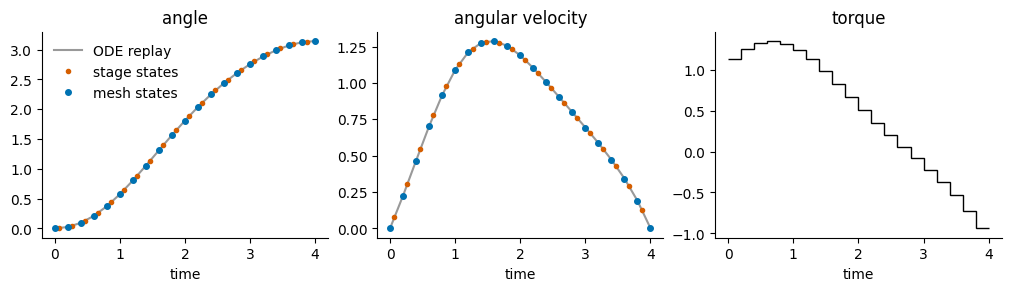

In [8]:
# @title Plot the stored states, the replay, and the torque
fig, axes = plt.subplots(1, 3, figsize=(10, 2.8), constrained_layout=True)
for i, name in enumerate(["angle", "angular velocity"]):
    axes[i].plot(t, x_replay[:, i], color="0.6", label="ODE replay")
    axes[i].plot(t_stage.ravel(), x_stage[:, :, i].ravel(), ".", color="#D55E00",
                 label="stage states")
    axes[i].plot(t, x_mesh[:, i], "o", color="#0072B2", markersize=4, label="mesh states")
    axes[i].set(xlabel="time", title=name)
axes[0].legend(frameon=False)
axes[2].stairs(u, t, baseline=None, color="black")
axes[2].set(xlabel="time", title="torque")
plt.show()

The difference from the replay, about $10^{-3}$, is the discretization error
of 20 intervals with the Radau rule. The second experiment at the end shows
how quickly it decreases as the number of intervals grows.

In the figure, the grey curves are the replayed pendulum and the dots are the
stored states. The dots lie on the curves, and the pendulum arrives upright
and at rest. The torque is largest early in the motion, while the pendulum
gains speed. From about $t=2.8$ it is negative. The pendulum then has more
energy than the amount needed at the top, and the motor removes the excess so
that the pendulum arrives at rest instead of swinging past the upright
position.

## The Same Construction with Derivatives

The integration form above builds each polynomial from the slopes and
requires the stored stage states to lie on it. The chapter's
[differentiation form](https://pierrelux.github.io/rlbook/continuous-time-collocation#alg-collocation-differentiation-from-nodes)
reverses the roles. It builds the polynomial from stored state values and
requires its slopes to match the ODE at the nodes. At a solution, both forms
express the same two facts: the polynomial passes through the stored states,
and its slope equals $\mathbf f$ at each node. They differ in which fact holds
by construction and which becomes a constraint.

On each interval the interpolated slope is a line, so the state polynomial is
a quadratic, and three values determine a quadratic. Store its values at
$\tau=0$ and at the two collocation nodes. These are $\mathbf x_k$,
$\mathbf x_{k,1}$, and $\mathbf x_{k,2}$, the same unknowns as before, so
$\mathbf z$, `unpack`, and `objective` do not change.

Let $\ell_0,\ell_1,\ell_2$ now denote the Lagrange basis for the three points
$(0,\tfrac{1}{3},1)$. The slope of the quadratic at a collocation node
$\tau_i$ is a weighted sum of the three stored values, with weights
$D_{ir}=\ell_r'(\tau_i)$. This sum plays the role of a finite-difference
formula, but it is exact for every quadratic. The slope is measured per unit
of local time, so it must equal $h$ times the ODE slope:

$$
D_{i0}\mathbf x_k+\sum_{r=1}^{s}D_{ir}\mathbf x_{k,r}=h\mathbf f_{k,i}.
$$

By hand, the basis functions are

$$
\ell_0(\tau)=3\tau^2-4\tau+1,\qquad
\ell_1(\tau)=-\tfrac{9}{2}\tau^2+\tfrac{9}{2}\tau,\qquad
\ell_2(\tau)=\tfrac{3}{2}\tau^2-\tfrac{1}{2}\tau,
$$

with derivatives $6\tau-4$, $-9\tau+\tfrac{9}{2}$, and $3\tau-\tfrac{1}{2}$.
Evaluating these derivatives at $\tfrac{1}{3}$ and at $1$ gives one row of $D$
per collocation node, and hence the two slope equations:

$$
D=\begin{bmatrix}
-2&\tfrac{3}{2}&\tfrac{1}{2}\cr
2&-\tfrac{9}{2}&\tfrac{5}{2}
\end{bmatrix},
\qquad
\begin{aligned}
-2\mathbf x_k+\tfrac{3}{2}\mathbf x_{k,1}+\tfrac{1}{2}\mathbf x_{k,2}
&=h\mathbf f_{k,1},\cr
2\mathbf x_k-\tfrac{9}{2}\mathbf x_{k,1}+\tfrac{5}{2}\mathbf x_{k,2}
&=h\mathbf f_{k,2}.
\end{aligned}
$$

Each row of $D$ sums to zero, because a constant state has zero slope. The
endpoint equation evaluates the quadratic at $\tau=1$ with the weights
$e_r=\ell_r(1)$. Here $e=(0,0,1)$ because $\tau=1$ is one of the stored
points, so the equation reduces to $\mathbf x_{k+1}=\mathbf x_{k,2}$.
Compared with the integration form, only the rule and two lines of the
constraint function change.

In [9]:
assert tau.min() > 0, "this section needs collocation nodes other than 0"

# D[i, r] is the slope of ell_r at tau_i, and e[r] is the value of ell_r at 1.
state_basis = lagrange_basis(np.append(0.0, tau))    # basis for the points 0, tau_1, ..., tau_s
D = np.array([[ell.deriv()(tau_i) for ell in state_basis] for tau_i in tau])
e = np.array([ell(1.0) for ell in state_basis])
show("D", D)
show("e", e)


def equalities_from_derivatives(z):                                     # H(z) = 0
    x_mesh, x_stage, u = unpack(z)
    residuals = [x_mesh[0] - x_start, x_mesh[N] - x_goal]               # boundary conditions
    for k in range(N):
        slopes = np.array([f(x_stage[k, j], u[k]) for j in range(s)])   # f at every stage
        values = np.vstack([x_mesh[k], x_stage[k]])                     # state at 0 and the nodes
        residuals.append(D @ values - h * slopes)                       # slope equations
        residuals.append(x_mesh[k + 1] - e @ values)                    # endpoint equation
    return np.concatenate([r.ravel() for r in residuals])


other = minimize(objective, z0, method="SLSQP", bounds=bounds,
                 constraints={"type": "eq", "fun": equalities_from_derivatives})
print(f"cost = {other.fun:.4f}")
print(f"largest difference between the two solutions = {abs(other.x - solution.x).max():.1e}")

D = [[-2, 3/2, 1/2], [2, -9/2, 5/2]]
e = [0, 0, 1]


cost = 3.0753
largest difference between the two solutions = 1.6e-07


Both programs have the same unknowns and the same objective, and their
constraints vanish at the same points, so the solver returns the same
trajectory up to its tolerance. Away from a solution the two residual vectors
differ, which can change the solver's iterations but not the set of solutions.

## Experiments

Each experiment changes a few lines. Run all cells again after a change.

The first experiment replaces the nodes in Step 1. The same code then
produces the other schemes of the chapter, because only the numbers in $A$
and $b$ change. The table lists the largest difference from the replay
obtained with $N=20$.

| `tau` | Scheme | Difference from the replay |
|:--|:--|:--|
| `np.array([0.0])` | explicit Euler | $7\times10^{-1}$ |
| `np.array([1.0])` | implicit Euler | $8\times10^{-1}$ |
| `np.array([0.5])` | implicit midpoint | $4\times10^{-2}$ |
| `np.array([0.0, 1.0])` | trapezoidal | $9\times10^{-3}$ |
| `np.array([1/3, 1.0])` | Radau, two stages | $1\times10^{-3}$ |
| `0.5 + np.array([-1, 1]) * np.sqrt(3) / 6` | Gauss, two stages | $3\times10^{-5}$ |
| `np.array([0.0, 0.5, 1.0])` | Hermite-Simpson | $6\times10^{-6}$ |

Every row satisfies its own collocation equations to the solver's tolerance.
The rows differ in how well those equations represent the differential
equation. A node at $0$ runs through Step 5 and stops at the first line of
the last section, which stores the state at $0$ and at the collocation nodes
and needs these to be distinct. For the Gauss nodes, `show` prints rounded
fractions because the exact entries are irrational.

The second experiment refines the mesh. With the Radau nodes, set `N` to 5,
10, 20, and 40. The difference from the replay falls by a factor of about
eight each time `N` doubles.

The third experiment bounds the torque. Set `T = 8.0` and `N = 40`, and
replace `bounds = None` in Step 5 by bounds on the last `N` entries of
$\mathbf z$:

```python
bounds = [(None, None)] * (len(z0) - N) + [(-0.5, 0.5)] * N
```

The pendulum's energy $\tfrac{1}{2}\omega^2+1-\cos\theta$ changes at the rate
$u\omega$. Reaching the top requires energy $2$, but one forward swing through
the angle $\pi$ adds at most $0.5\pi\approx1.57$. The solver returns a
trajectory that first swings backward.

## Summary

The demo turned a continuous-time problem into 142 numbers and 124 equations.
The rule $A$, $b$ depends only on the nodes and is computed once by exact
polynomial calculus. The stage equations make the polynomial on each interval
satisfy the ODE at the nodes, the endpoint equations join the pieces, and the
same weights integrate the cost. The solver's residual shows that the finite
equations hold, and the replay measures how well they represent the pendulum.
Changing the nodes, the number of intervals, or the model changes a line or a
cell, and the construction stays the same. The chapter
[Continuous-Time Transcription and Collocation](https://pierrelux.github.io/rlbook/continuous-time-collocation) develops each step in
general, including controls that vary within an interval and constraints
checked between nodes.